<p style="background-color:#1A2D45;font-family:newtimeroman; color:white;text-align:center;border-radius:10px;font-size:24px">We are all astronauts on spaceship Kaggle!</p>
<center>
    <img src="https://i.postimg.cc/Dy1zQGsq/image.png" style="border-radius:40px;font-size:24px;" alt="Abdirayimov Sardor">
</center>




<p id="problemdefinition" style="background-color:#1A2D45;font-family:newtimeroman;color:#FFF9ED;font-size:24px;text-align:center;border-radius:10px;"> Problem Definition 🌌</p>

How Disaster happened?

While rounding Alpha Centauri en route to its first destination—the torrid 55 Cancri E—the unwary Spaceship Titanic collided with a spacetime anomaly hidden within a dust cloud. Sadly, it met a similar fate as its namesake from 1000 years before. Though the ship stayed intact, almost half of the passengers were transported to an alternate dimension!

Summary:
- the ship stayed intact
- Spaceship Titanic collided with a spacetime anomaly hidden within a dust cloud
- almost half of the passengers were transported to an alternate dimension

We as a human being know only 3 or 4 dimensions. However the Vedas said about presenting 64 dimensions.
![dimentions](https://i.postimg.cc/3RBFFTFJ/image.png)

**What is transporting means, if the Spaceship stayed intact?**

Let\`s look at the dataset to understand process of transporting


<p id="loadthedataset" style="background-color:#1A2D45;font-family:newtimeroman;color:#FFF9ED;font-size:24px;text-align:center;border-radius:10px;"> Load the Dataset 🗄</p>

In [1]:
from pandas.plotting import scatter_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
import matplotlib as mpl

mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=["#1A2D45", "#546981", "#425a61"]) 

In [2]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('seaborn-whitegrid')
# Set Matplotlib defaults
plt.rc('figure', autolayout=True)
plt.rc('axes', labelweight='bold', labelsize='large',
       titleweight='bold', titlesize=18, titlepad=10)
plt.rc('animation', html='html5')

import os
import warnings
warnings.filterwarnings("ignore")


for dirname, _, filenames in os.walk('/kaggle/input'):   
     for filename in filenames:
        name = os.path.join(dirname, filename)
        if "train_with_no" in name:                   
            train = pd.read_csv(name)                
        elif "test_with_no" in name:
            test = pd.read_csv(name)              
        elif "submission.csv" in name:
            sample = pd.read_csv(name)

<p id="validation" style="background-color:#1A2D45;font-family:newtimeroman;color:#FFF9ED;font-size:24px;text-align:center;border-radius:10px;">Validation Dataset 🎛</p>

In [3]:
X = train.copy()
y = X.pop("Transported")
X.drop(["PassengerId", "Family"], axis=1, inplace=True)
X = pd.get_dummies(X)

In [4]:
X['CryoSleep'] = X['CryoSleep'].map({False: 0, True:1})
X['VIP'] = X['VIP'].map({False: 0, True:1})

In [5]:
from sklearn.preprocessing import LabelEncoder


encoder = LabelEncoder()
y_for_train = encoder.fit_transform(y)
y_for_train

array([0, 1, 0, ..., 1, 0, 1])

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=17)

In [7]:
X_train.head()

,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Cabin_num,Group,...,Deck_A,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Side_P,Side_S
3810,0,24.0,0,0.0,0.0,2433.0,0.0,53.0,768,4069,...,0,0,0,0,0,1,0,0,0,1
64,0,29.0,0,793.0,0.0,2.0,253.0,0.0,4,68,...,0,0,0,0,1,0,0,0,0,1
7762,0,61.0,0,67.0,0.0,654.0,0.0,86.0,1336,8282,...,0,0,0,0,0,0,1,0,0,1
8687,0,30.0,0,0.0,3208.0,0.0,2.0,330.0,97,9275,...,1,0,0,0,0,0,0,0,1,0
1948,0,65.0,0,51.0,4451.0,0.0,20.0,397.0,26,2086,...,1,0,0,0,0,0,0,0,0,1


In [8]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.BatchNormalization(input_shape=[27]),
    layers.Dense(1024, activation='relu', input_shape=[27]),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(1024, activation='relu'),    
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid'),
])

2022-03-22 13:46:01.901302: I tensorflow/core/common_runtime/process_util.cc:146] Creating new thread pool with default inter op setting: 2. Tune using inter_op_parallelism_threads for best performance.


In [9]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['binary_accuracy'],
)

In [10]:
early_stopping = keras.callbacks.EarlyStopping(
    patience=10,
    min_delta=0.001,
    restore_best_weights=True,
)


history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    batch_size=512,
    epochs=100,
    callbacks=[early_stopping],
)

2022-03-22 13:46:02.233919: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)


Epoch 1/100
12/12 [==============================] - 2s 80ms/step - loss: 0.6913 - binary_accuracy: 0.7332 - val_loss: 0.5925 - val_binary_accuracy: 0.6602
Epoch 2/100
12/12 [==============================] - 1s 54ms/step - loss: 0.5909 - binary_accuracy: 0.7526 - val_loss: 0.5747 - val_binary_accuracy: 0.6797
Epoch 3/100
12/12 [==============================] - 1s 61ms/step - loss: 0.5076 - binary_accuracy: 0.7685 - val_loss: 0.5474 - val_binary_accuracy: 0.7121
Epoch 4/100
12/12 [==============================] - 1s 54ms/step - loss: 0.4990 - binary_accuracy: 0.7670 - val_loss: 0.5472 - val_binary_accuracy: 0.7062
Epoch 5/100
12/12 [==============================] - 1s 54ms/step - loss: 0.4721 - binary_accuracy: 0.7761 - val_loss: 0.5349 - val_binary_accuracy: 0.7239
Epoch 6/100
12/12 [==============================] - 1s 61ms/step - loss: 0.4735 - binary_accuracy: 0.7770 - val_loss: 0.5385 - val_binary_accuracy: 0.7170
Epoch 7/100
12/12 [==============================] - 1s 54ms/ste

Best Validation Loss: 0.3979
Best Validation Accuracy: 0.8167


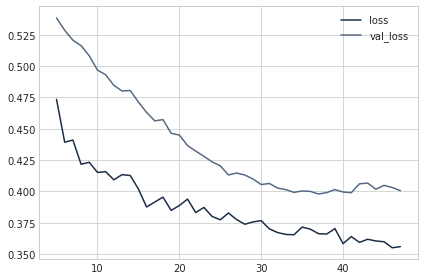

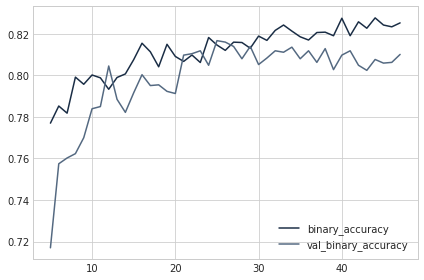

In [11]:
history_df = pd.DataFrame(history.history)
# Start the plot at epoch 5
history_df.loc[5:, ['loss', 'val_loss']].plot()
history_df.loc[5:, ['binary_accuracy', 'val_binary_accuracy']].plot()

print(("Best Validation Loss: {:0.4f}" +\
      "\nBest Validation Accuracy: {:0.4f}")\
      .format(history_df['val_loss'].min(), 
              history_df['val_binary_accuracy'].max()))

In [12]:
final_test = pd.get_dummies(test.drop(['PassengerId', 'Family', 'Transported'], axis=1))
final_test['CryoSleep'] = final_test['CryoSleep'].map({False: 0, True:1})
final_test['VIP'] = final_test['VIP'].map({False: 0, True:1})

In [13]:
ypred = model.predict(final_test).round()

In [14]:
sample.Transported = ypred
sample.Transported = sample.Transported.map({1: True, 0: False})

In [15]:
sample.to_csv("NN_Class.csv", index=False)

Do not Forget to check my First kernel about detailed ways of [dealing with missing values](https://www.kaggle.com/code/sardorabdirayimov/best-way-of-dealing-with-missing-values-titanic-2)

<a href="#top" class="btn btn-success btn-lg active" role="button" aria-pressed="true" style="color:#1A2D45;" data-toggle="popover" title="go to Colors">Go to TOP</a>